# Gene-expression programs and the copy-number confound

Beyond copy number, malignant cells run **gene-expression programs** — coordinated modules
(proliferation, EMT, hypoxia, …) that a factor model (NMF, cNMF, scDEF) tries to recover from scRNA.
iscc's R13 program layer plants a **known** loading matrix, so we can score recovery — and expose the
central confound:

> **CNAs are contiguous; programs are scattered.** A copy-number gain co-regulates a whole *genomic
> segment* of genes at once, which a factor model can absorb as a spurious "program". A real program's
> genes are **scattered across the genome**. The statistic that separates them is exactly that —
> whether a factor's top genes are **positionally clustered** (a CNA artefact) or **scattered** (a
> program).

And a real scRNA study sees **all cell types**, so a factor model must *also* separate **cell-type
identity** (malignant vs microenvironment) from **within-malignant programs**. We analyse the mixture
throughout.

> The full tool benchmark (scDEF / cNMF, and how recovery degrades with CNA burden) is
> `validation/validate_programs.py`.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
import programs_common as PC      # positional_clustering / scattered_null diagnostics
from iscc.data import scRNA

## 1. Grow the tumour and assay the mixture

The shared substrate has the program layer on. We assay a realistic-purity mixture and keep the true
per-cell program activities (`cell_program`) and the true loading (`program_truth`) to score against.

In [2]:
t = B.grow_base_tumor()
cd = t.cell_data
types = B.cell_types(t)
idx = np.asarray(cd["cell_type"].index)
is_cancer = types == "cancer"

pt = t.program_truth
loading = np.asarray(pt["loading"])            # K_programs x genes
prog_names = list(pt["program_names"])
K = len(prog_names)
seg_sizes = np.asarray(t.selection.segment_sizes)
print(f"{K} planted programs: {prog_names}")
print(f"loading matrix: {loading.shape} (programs x genes)")

rng = np.random.default_rng(0)
cancer_cells = list(rng.choice(idx[is_cancer], size=500, replace=False))
normal_cells = list(rng.choice(idx[np.isin(types, ("epithelial", "stromal"))], size=350, replace=False))
mixture = cancer_cells + normal_cells
pos = {c: i for i, c in enumerate(idx)}
mix_pos = np.array([pos[c] for c in mixture])
is_mal_mix = np.isin(mixture, cancer_cells)
print(f"assayed mixture: {len(mixture)} cells | purity {is_mal_mix.mean():.0%}")

6 planted programs: ['proliferation', 'emt', 'hypoxia', 'drug_resistance', 'immune_evasion', 'program_5']
loading matrix: (6, 600) (programs x genes)
assayed mixture: 850 cells | purity 59%


## 2. Programs track the underlying biology

A program is not decoration — in iscc each is **coupled to a phenotype or a niche field**, so its
activity has a *reason*. Three of the planted programs have a known driver:

* **proliferation** tracks the **division rate** (CINner fitness),
* **EMT** tracks the **dispersal rate** (motility),
* **hypoxia** tracks the O₂-starved **core** (the perfused-stroma field).

Below, each malignant cell's program activity is plotted against its driver — spatially (top) and as a
scatter (bottom). The correlations are the ground-truth link a real study can only *hope* its factors
recover. (Proliferation and division are on very different scales — division saturates at
`max_birth_rate` while dispersal is unbounded — so the program *gains* are set per phenotype in
`base_sim.EXPR()`; that is why all three track comparably.)

proliferation~division r=0.99 | EMT~dispersal r=0.99 | hypoxia~core r=0.76


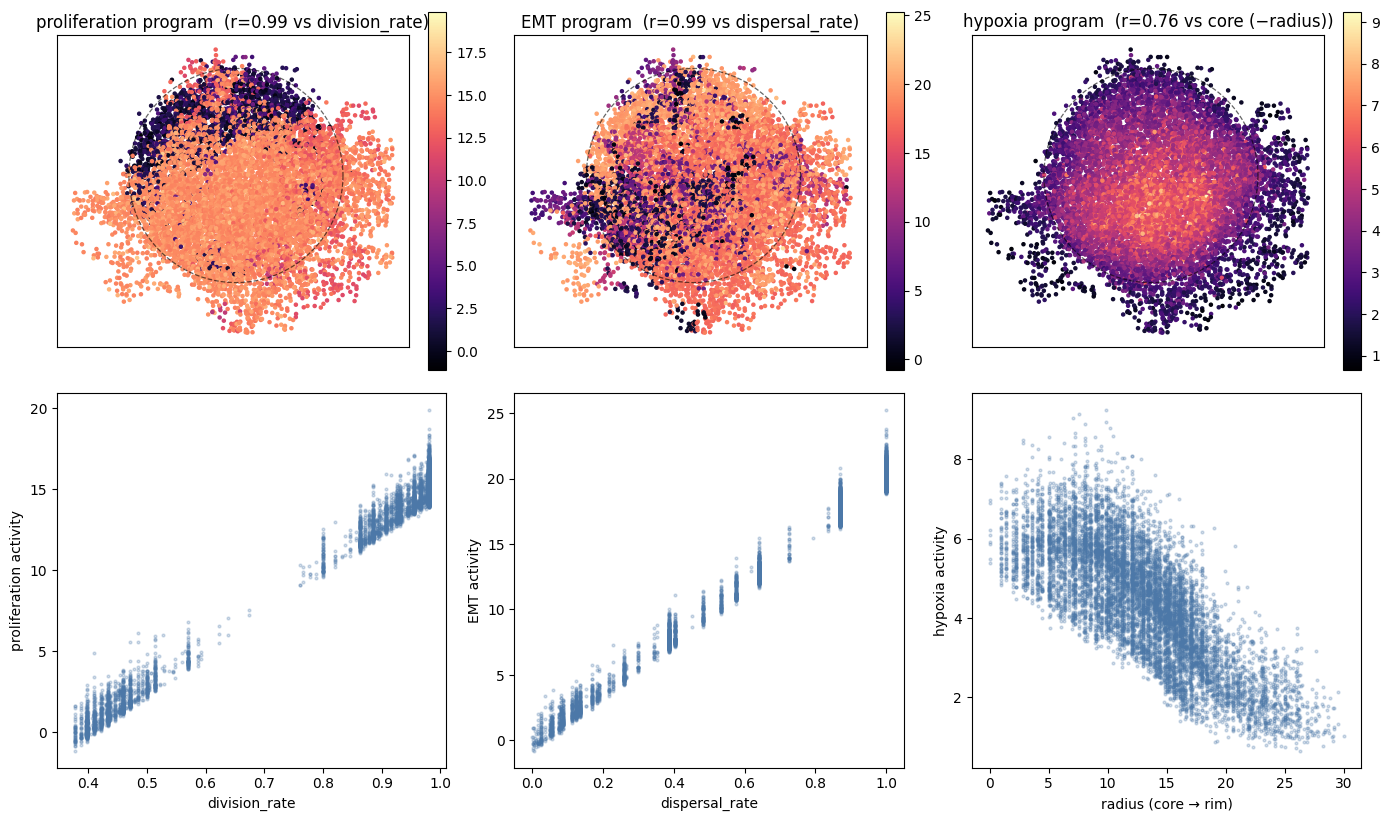

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.45, 0.45, len(crd))
jy = crd["row"].values + jit.uniform(-0.45, 0.45, len(crd))

div  = B.cell_rate(t, "division_rate")
disp = B.cell_rate(t, "dispersal_rate")
rad  = B.cell_radius(t)
prol = B.cell_program(t, "proliferation")
emt  = B.cell_program(t, "emt")
hyp  = B.cell_program(t, "hypoxia")

cp = cd["cell_program"].values                 # cells x K; dominant program per cancer cell (used in §4)
dom = np.full(len(idx), -1)
dom[is_cancer] = cp[is_cancer].argmax(1)

def _corr(a, b):
    ok = is_cancer & np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(a[ok], b[ok])[0, 1])

pairs = [("proliferation", prol, div,  "division_rate", "magma"),
         ("EMT",           emt,  disp, "dispersal_rate", "magma"),
         ("hypoxia",       hyp, -rad,  "core (−radius)", "magma")]

fig, ax = plt.subplots(2, 3, figsize=(14, 8.4))
for j, (pname, pz, drv, dname, cmap) in enumerate(pairs):
    r = _corr(pz, drv)
    m = is_cancer & np.isfinite(pz)
    sc = ax[0, j].scatter(jx[m], jy[m], s=5, c=pz[m], cmap=cmap)
    B.gland_ring(ax[0, j]); ax[0, j].set_aspect("equal"); ax[0, j].invert_yaxis()
    ax[0, j].set_xticks([]); ax[0, j].set_yticks([])
    ax[0, j].set_title(f"{pname} program  (r={r:.2f} vs {dname})")
    plt.colorbar(sc, ax=ax[0, j], fraction=0.046)
    xv = drv[m] if pname != "hypoxia" else rad[m]
    ax[1, j].scatter(xv, pz[m], s=4, alpha=0.25, color="#4c78a8")
    ax[1, j].set_xlabel(dname if pname != "hypoxia" else "radius (core → rim)")
    ax[1, j].set_ylabel(f"{pname} activity")
plt.tight_layout()
print(f"proliferation~division r={_corr(prol,div):.2f} | "
      f"EMT~dispersal r={_corr(emt,disp):.2f} | hypoxia~core r={_corr(hyp,-rad):.2f}")

## 3. The true loading — programs are scattered

A program's genes are spread **across the genome**, not packed into one segment. Tallying program 0's
top genes by genomic segment shows them scattered across all chromosomes — the defining contrast with a
copy-number event, which would land entirely in one segment.

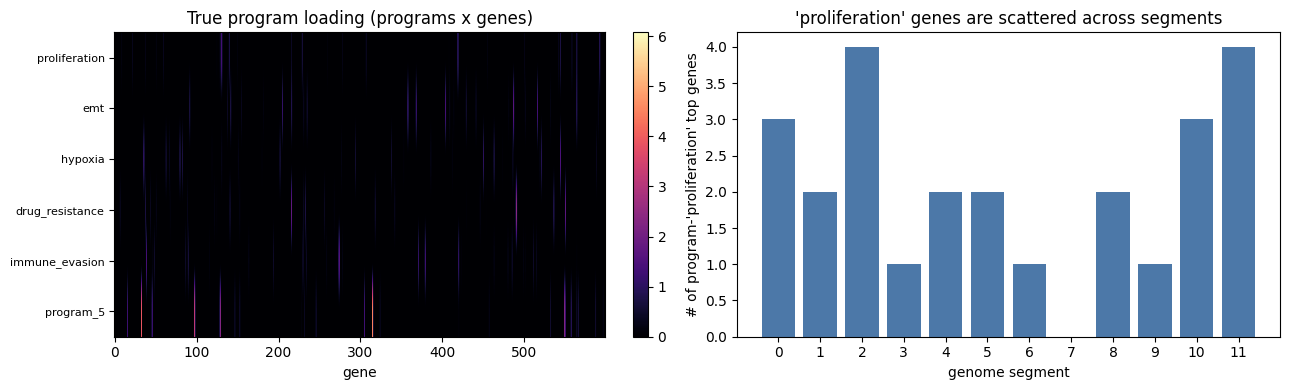

In [4]:
offs = np.concatenate([[0], np.cumsum(seg_sizes)]).astype(int)
def seg_of(gene_ix):
    return np.searchsorted(offs, gene_ix, side="right") - 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(loading, aspect="auto", cmap="magma")
axes[0].set_yticks(range(K)); axes[0].set_yticklabels(prog_names, fontsize=8)
axes[0].set_xlabel("gene"); axes[0].set_title("True program loading (programs x genes)")
plt.colorbar(im, ax=axes[0], fraction=0.046)

top0 = np.argsort(loading[0])[::-1][:25]
seg_counts = np.bincount(seg_of(top0), minlength=len(seg_sizes))
axes[1].bar(range(len(seg_sizes)), seg_counts, color="#4c78a8")
axes[1].set_xlabel("genome segment"); axes[1].set_ylabel(f"# of program-'{prog_names[0]}' top genes")
axes[1].set_title(f"'{prog_names[0]}' genes are scattered across segments")
axes[1].set_xticks(range(len(seg_sizes)))
plt.tight_layout()

## 4. The mixture: cell-type identity vs within-malignant programs

Embedding the mixture (PCA of the scRNA counts), the **first** axis of variation is cell-type identity
— malignant vs microenvironment separate cleanly. The programs live *within* the malignant cloud. A
factor model must recover both levels: one factor for the cell-type split, and the rest for the
programs.

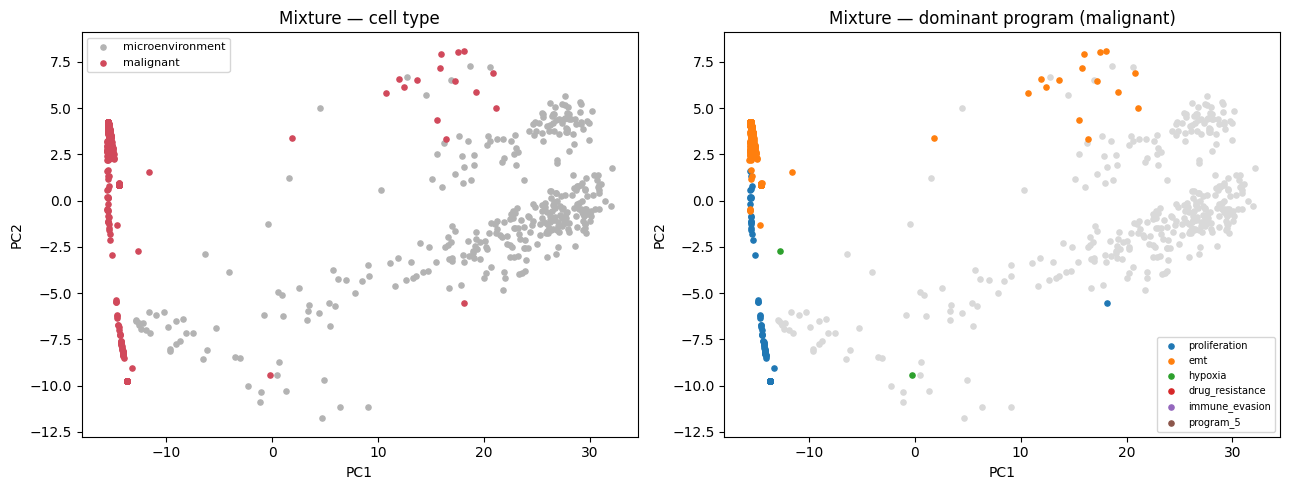

In [5]:
from sklearn.decomposition import PCA

rna = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd, cell_subset=mixture)
Y = rna.observed_counts
rna_cells = list(Y.index)
is_mal = np.isin(rna_cells, cancer_cells)
Yv = Y.values.astype(float)
Ycpm = Yv / np.where(Yv.sum(1, keepdims=True) > 0, Yv.sum(1, keepdims=True), 1) * 1e4
Ylog = np.log1p(Ycpm)
pcs = PCA(n_components=10, random_state=0).fit_transform(Ylog - Ylog.mean(0))

dom_mix = np.array([dom[pos[c]] for c in rna_cells])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pcs[~is_mal, 0], pcs[~is_mal, 1], s=14, c="0.7", label="microenvironment")
axes[0].scatter(pcs[is_mal, 0], pcs[is_mal, 1], s=14, c="#d1495b", label="malignant")
axes[0].legend(fontsize=8); axes[0].set_title("Mixture — cell type")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
cmap = plt.get_cmap("tab10")
axes[1].scatter(pcs[~is_mal, 0], pcs[~is_mal, 1], s=14, c="0.85")
for k in range(K):
    m = is_mal & (dom_mix == k)
    axes[1].scatter(pcs[m, 0], pcs[m, 1], s=14, color=cmap(k), label=prog_names[k])
axes[1].legend(fontsize=7); axes[1].set_title("Mixture — dominant program (malignant)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()

## 5. The diagnostic: positional clustering

`positional_clustering` takes a factor's top genes and returns the largest fraction landing in any one
segment. A genuine program sits near the **scattered null** (dashed band, estimated by random gene
sets); a factor that has absorbed a copy-number segment approaches **1.0**. Below: every true program
scores near the null, while a synthetic "pseudo-factor" made of one contiguous CNA segment pins at 1.0.

scattered null: mean 0.18, 95% 0.24
true programs: [0.16, 0.2, 0.16, 0.12, 0.16, 0.24]   |  CNA pseudo-factor: 1.00


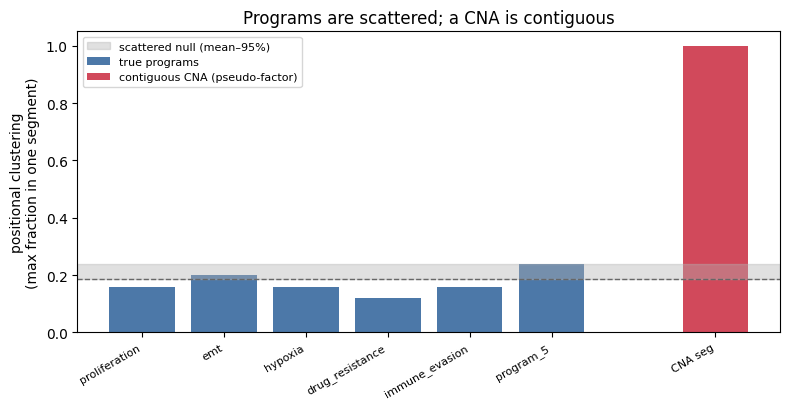

In [6]:
null_mean, null_95 = PC.scattered_null(seg_sizes, top_n=25)
prog_clust = [PC.positional_clustering(loading[k], seg_sizes, top_n=25) for k in range(K)]
# a pseudo-factor that is exactly one contiguous copy-number segment
pseudo = np.zeros(loading.shape[1]); pseudo[offs[3]:offs[4]] = 1.0
pseudo_clust = PC.positional_clustering(pseudo, seg_sizes, top_n=25)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(K), prog_clust, color="#4c78a8", label="true programs")
ax.bar([K + 1], [pseudo_clust], color="#d1495b", label="contiguous CNA (pseudo-factor)")
ax.axhspan(null_mean, null_95, color="0.7", alpha=0.4, label="scattered null (mean–95%)")
ax.axhline(null_mean, color="0.4", ls="--", lw=1)
ax.set_xticks(list(range(K)) + [K + 1])
ax.set_xticklabels(prog_names + ["CNA seg"], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("positional clustering\n(max fraction in one segment)")
ax.set_title("Programs are scattered; a CNA is contiguous")
ax.legend(fontsize=8)
plt.tight_layout()
print(f"scattered null: mean {null_mean:.2f}, 95% {null_95:.2f}")
print(f"true programs: {np.round(prog_clust,2).tolist()}   |  CNA pseudo-factor: {pseudo_clust:.2f}")

## 6. Self-contained recovery: NMF on the mixture

A plain NMF on the mixture counts (given room for the cell-type factor) recovers the **stronger**
programs — Hungarian-matching each true program to its best NMF factor gives a good cosine for several
of them — while the subtler programs are confounded by the dominant cell-type and CNA structure. This
is the honest limit of an off-the-shelf factorisation, and exactly why the dedicated tools (scDEF /
cNMF, with hierarchical / consensus priors) exist. Reassuringly, whatever it *does* recover is
**scattered** (near the null), not a copy-number segment; one extra factor separates the
microenvironment.

per-program recovery (true program -> best NMF factor):
  proliferation    cosine 0.52   positional-clustering 0.16
  emt              cosine 0.49   positional-clustering 0.16
  hypoxia          cosine 0.43   positional-clustering 0.16
  drug_resistance  cosine 0.68   positional-clustering 0.12
  immune_evasion   cosine 0.02   positional-clustering 0.20
  program_5        cosine 0.57   positional-clustering 0.20

mean matched cosine: 0.45
cell-type factor (separates normal vs malignant): factor 4


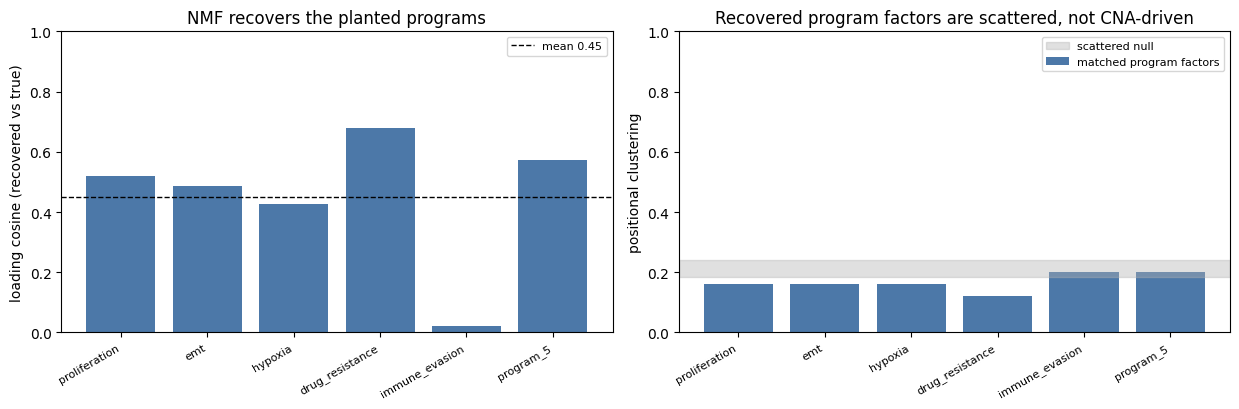

In [7]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else float(a @ b / (na * nb))

nmf = NMF(n_components=K + 2, init="nndsvda", max_iter=400, random_state=0)
Wcell = nmf.fit_transform(Ycpm)                # cells x factors
Hfac = nmf.components_                          # factors x genes

C = np.array([[cosine(loading[i], Hfac[j]) for j in range(Hfac.shape[0])] for i in range(K)])
rows, cols = linear_sum_assignment(-C)
matched_cos = C[rows, cols]
# which factor best marks the microenvironment? the one whose activity most separates normal vs malig
sep = [abs(Wcell[is_mal, j].mean() - Wcell[~is_mal, j].mean()) / (Wcell[:, j].std() + 1e-9)
       for j in range(Hfac.shape[0])]
celltype_factor = int(np.argmax(sep))
matched_clust = [PC.positional_clustering(Hfac[j], seg_sizes, 25) for j in cols]

print("per-program recovery (true program -> best NMF factor):")
for i, j, cc in zip(rows, cols, matched_cos):
    print(f"  {prog_names[i]:<16s} cosine {cc:.2f}   positional-clustering {PC.positional_clustering(Hfac[j], seg_sizes,25):.2f}")
print(f"\nmean matched cosine: {matched_cos.mean():.2f}")
print(f"cell-type factor (separates normal vs malignant): factor {celltype_factor}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].bar(range(K), matched_cos, color="#4c78a8")
axes[0].axhline(matched_cos.mean(), color="k", ls="--", lw=1, label=f"mean {matched_cos.mean():.2f}")
axes[0].set_xticks(range(K)); axes[0].set_xticklabels(prog_names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("loading cosine (recovered vs true)"); axes[0].set_ylim(0, 1)
axes[0].set_title("NMF recovers the planted programs"); axes[0].legend(fontsize=8)

axes[1].bar(range(K), matched_clust, color="#4c78a8", label="matched program factors")
axes[1].axhspan(null_mean, null_95, color="0.7", alpha=0.4, label="scattered null")
axes[1].set_xticks(range(K)); axes[1].set_xticklabels(prog_names, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("positional clustering"); axes[1].set_ylim(0, 1)
axes[1].set_title("Recovered program factors are scattered, not CNA-driven")
axes[1].legend(fontsize=8)
plt.tight_layout()

## What this shows

* Each program **tracks a real driver** — proliferation↔division, EMT↔dispersal, hypoxia↔core — so the
  expression layer is a readout of the underlying evolutionary/microenvironmental state, not noise.
* iscc plants **known** gene-expression programs (`program_truth`), so program recovery is scorable —
  ground truth no real scRNA dataset provides.
* The programs are **scattered across the genome**, the defining contrast with a **contiguous** copy-
  number event; `positional_clustering` (vs the scattered null) is the statistic that tells a real
  program from a CNA dressed up as one.
* A self-contained **NMF on the mixture** recovers the stronger programs (and whatever it recovers is
  scattered, not CNA-driven) while a separate factor absorbs the microenvironment — an honest floor,
  well below what the dedicated tools (scDEF / cNMF) achieve, on the emergent signal they exploit.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) · [`cohort_shared_programs`](cohort_shared_programs.ipynb)
(recovering the *same* programs across a 5-patient cohort) ·
[`assay_scrna`](assay_scrna.ipynb) (the scRNA count model) ·
`validation/validate_programs.py` (the scDEF / cNMF benchmark + CNA-burden sweep).